### RETINAL VESSEL SEGMENTATION USING SWIN U-NET MODEL

In [1]:
import os

file_path = r"C:\Users\HP PC\Downloads\DRIVE"

print(os.listdir(file_path))

['test', 'training']


### Training Paths

In [2]:
training_path = os.path.join(
    file_path,
    "training"
)

print(os.listdir(training_path))

['1st_manual', 'images', 'mask']


### Swin-UNet Pipeline

This time our roadmap is:

* Load DRIVE
      ↓
* Create Dataset
      ↓
* Split 16 / 4
      ↓
* DataLoader
      ↓
* Verify Shapes
      ↓
* Build Swin-UNet
      ↓
* Dice Loss
      ↓
* Adam Optimizer
      ↓
* 50 Epoch Training
      ↓
* Save Best Model
      ↓
* Visual Comparison

### Create Paths

In [3]:
image_dir = os.path.join(
    training_path,
    "images"
)

mask_dir = os.path.join(
    training_path,
    "1st_manual"
)

fov_dir = os.path.join(
    training_path,
    "mask"
)

print(len(os.listdir(image_dir)))
print(len(os.listdir(mask_dir)))
print(len(os.listdir(fov_dir)))

20
20
20


### Create Dataset Class

Use the original dataset class (no augmentation for now).

In [4]:
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset


class DriveDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir,
        fov_dir
    ):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.fov_dir = fov_dir

        self.image_files = sorted(
            os.listdir(image_dir)
        )

        self.mask_files = sorted(
            os.listdir(mask_dir)
        )

        self.fov_files = sorted(
            os.listdir(fov_dir)
        )

    def __len__(self):

        return len(self.image_files)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.image_dir,
            self.image_files[idx]
        )

        mask_path = os.path.join(
            self.mask_dir,
            self.mask_files[idx]
        )

        image = Image.open(
            image_path
        ).convert("L")

        mask = Image.open(
            mask_path
        ).convert("L")

        image = np.array(image) / 255.0
        mask = np.array(mask) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

### Create Full Dataset

In [5]:
dataset = DriveDataset(
    image_dir,
    mask_dir,
    fov_dir
)

print(len(dataset))

20


### Create 16 / 4 Split

Use the same split strategy as before:

In [6]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(
    dataset,
    [16, 4]
)

print(len(train_dataset))
print(len(val_dataset))

16
4


### DataLoaders

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

### Verify Shapes

In [8]:
images, masks = next(
    iter(train_loader)
)

print(images.shape)
print(masks.shape)

torch.Size([2, 1, 584, 565])
torch.Size([2, 1, 584, 565])


In [9]:
import monai

print(monai.__version__)

1.4.0


### Recommended Workflow
DRIVE
      ↓
* Resize 512×512
      ↓
* Dataset
      ↓
* 16/4 Split
      ↓
* DataLoader
      ↓
* SwinUNETR
      ↓
* Dice + BCE
      ↓
* AdamW
      ↓
* 50 Epoch Training
      ↓
* Visual Comparison

###  Swin-Net  clean dataset class

In [10]:
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
import os


class DriveDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir,
        fov_dir,
        image_size=512
    ):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.fov_dir = fov_dir
        self.image_size = image_size

        self.image_files = sorted(
            os.listdir(image_dir)
        )

        self.mask_files = sorted(
            os.listdir(mask_dir)
        )

        self.fov_files = sorted(
            os.listdir(fov_dir)
        )

    def __len__(self):

        return len(self.image_files)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.image_dir,
            self.image_files[idx]
        )

        mask_path = os.path.join(
            self.mask_dir,
            self.mask_files[idx]
        )

        image = Image.open(
            image_path
        ).convert("L")

        mask = Image.open(
            mask_path
        ).convert("L")

        # Resize for Swin-UNet

        image = image.resize(
            (self.image_size, self.image_size),
            Image.BILINEAR
        )

        mask = mask.resize(
            (self.image_size, self.image_size),
            Image.NEAREST
        )

        image = np.array(image) / 255.0

        mask = np.array(mask) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

### Create swin-Unet Dataset

In [11]:
dataset = DriveDataset(
    image_dir,
    mask_dir,
    fov_dir,
    image_size=512
)

print(len(dataset))

20


### Create Split

In [12]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(
    dataset,
    [16, 4]
)

print(len(train_dataset))
print(len(val_dataset))

16
4


### Create DataLoaders

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

### Verify Shapes

In [14]:
images, masks = next(
    iter(train_loader)
)

print(images.shape)
print(masks.shape)

torch.Size([2, 1, 512, 512])
torch.Size([2, 1, 512, 512])


### Create SwinUNETR

In [ ]:
import timm

print(timm.__version__)

In [17]:
import timm

print(timm.__version__)

1.0.19


In [18]:
import torch
print(torch.__version__)

2.3.1


In [19]:
import timm

model_names = timm.list_models("*swin*")

print(model_names[:20])
print("\nTotal:", len(model_names))

['hiera_base_abswin_256', 'hiera_small_abswin_256', 'swin_base_patch4_window7_224', 'swin_base_patch4_window12_384', 'swin_large_patch4_window7_224', 'swin_large_patch4_window12_384', 'swin_s3_base_224', 'swin_s3_small_224', 'swin_s3_tiny_224', 'swin_small_patch4_window7_224', 'swin_tiny_patch4_window7_224', 'swinv2_base_window8_256', 'swinv2_base_window12_192', 'swinv2_base_window12to16_192to256', 'swinv2_base_window12to24_192to384', 'swinv2_base_window16_256', 'swinv2_cr_base_224', 'swinv2_cr_base_384', 'swinv2_cr_base_ns_224', 'swinv2_cr_giant_224']

Total: 39


In [22]:
import timm
import torch

encoder = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    features_only=True,
    img_size=512
)

print("Encoder Created")

x = torch.randn(
    1,
    3,
    512,
    512
)

features = encoder(x)

for i, f in enumerate(features):
    print(
        f"Feature {i}: {f.shape}"
    )

Encoder Created
Feature 0: torch.Size([1, 128, 128, 96])
Feature 1: torch.Size([1, 64, 64, 192])
Feature 2: torch.Size([1, 32, 32, 384])
Feature 3: torch.Size([1, 16, 16, 768])


### Decoder Block

In [23]:
import torch
import torch.nn as nn


class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = nn.Sequential(

            nn.Conv2d(
                out_channels + skip_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(
        self,
        x,
        skip
    ):

        x = self.up(x)

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.conv(x)

        return x

### Swin U-Net Architecture

In [24]:
import timm
import torch
import torch.nn as nn


class SwinUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=False,
            features_only=True,
            img_size=512
        )

        self.decoder3 = DecoderBlock(
            768,
            384,
            384
        )

        self.decoder2 = DecoderBlock(
            384,
            192,
            192
        )

        self.decoder1 = DecoderBlock(
            192,
            96,
            96
        )

        self.final_up = nn.ConvTranspose2d(
            96,
            64,
            kernel_size=4,
            stride=4
        )

        self.final_conv = nn.Sequential(

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                1,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        # replicate grayscale → RGB

        x = x.repeat(
            1,
            3,
            1,
            1
        )

        features = self.encoder(x)

        f0, f1, f2, f3 = features

        # HWC -> CHW

        f0 = f0.permute(
            0, 3, 1, 2
        )

        f1 = f1.permute(
            0, 3, 1, 2
        )

        f2 = f2.permute(
            0, 3, 1, 2
        )

        f3 = f3.permute(
            0, 3, 1, 2
        )

        d3 = self.decoder3(
            f3,
            f2
        )

        d2 = self.decoder2(
            d3,
            f1
        )

        d1 = self.decoder1(
            d2,
            f0
        )

        out = self.final_up(
            d1
        )

        out = self.final_conv(
            out
        )

        return out

### Instantiate

In [25]:
swin_model = SwinUNet()

print(
    "Swin U-Net Created Successfully"
)

Swin U-Net Created Successfully


### Forward Pass Test

This is the most important test.

In [26]:
images, masks = next(
    iter(train_loader)
)

outputs = swin_model(
    images
)

print(
    "Images:",
    images.shape
)

print(
    "Masks:",
    masks.shape
)

print(
    "Outputs:",
    outputs.shape
)

Images: torch.Size([2, 1, 512, 512])
Masks: torch.Size([2, 1, 512, 512])
Outputs: torch.Size([2, 1, 512, 512])


### BCE Loss

In [27]:
import torch.nn as nn

bce_loss = nn.BCELoss()

### Dice Loss

In [29]:
class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1e-6
    ):

        super().__init__()

        self.smooth = smooth

    def forward(
        self,
        preds,
        targets
    ):

        preds = preds.view(-1)

        targets = targets.view(-1)

        intersection = (
            preds * targets
        ).sum()

        dice = (
            2 * intersection
            + self.smooth
        ) / (
            preds.sum()
            + targets.sum()
            + self.smooth
        )

        return 1 - dice

### Create Dice Loss

In [30]:
dice_loss = DiceLoss()

### Dice Score Metric

This is for monitoring validation performance:

In [31]:
def dice_score(
    preds,
    targets,
    smooth=1e-6
):

    preds = (
        preds > 0.2
    ).float()

    preds = preds.view(-1)

    targets = targets.view(-1)

    intersection = (
        preds * targets
    ).sum()

    dice = (
        2 * intersection
        + smooth
    ) / (
        preds.sum()
        + targets.sum()
        + smooth
    )

    return dice.item()

### Optimizer

For transformer models, use AdamW instead of Adam.

In [32]:
import torch.optim as optim

optimizer = optim.AdamW(
    swin_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

### Sanity Check Before Training

In [33]:
images, masks = next(
    iter(train_loader)
)

outputs = swin_model(images)

print(
    "Output Min:",
    outputs.min().item()
)

print(
    "Output Max:",
    outputs.max().item()
)

print(
    "Output Mean:",
    outputs.mean().item()
)

Output Min: 0.5006201267242432
Output Max: 0.5877018570899963
Output Mean: 0.5432937741279602


### Complete Swin-U-Net training loop

In [34]:
best_dice = 0

num_epochs = 50

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================

    swin_model.train()

    train_loss = 0

    for images, masks in train_loader:

        outputs = swin_model(images)

        bce = bce_loss(
            outputs,
            masks
        )

        dice = dice_loss(
            outputs,
            masks
        )

        loss = bce + dice

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = (
        train_loss / len(train_loader)
    )

    # =========================
    # VALIDATION
    # =========================

    swin_model.eval()

    val_loss = 0

    val_dice = 0

    with torch.no_grad():

        for val_images, val_masks in val_loader:

            val_outputs = swin_model(
                val_images
            )

            bce = bce_loss(
                val_outputs,
                val_masks
            )

            dice = dice_loss(
                val_outputs,
                val_masks
            )

            loss = bce + dice

            val_loss += loss.item()

            val_dice += dice_score(
                val_outputs,
                val_masks
            )

    avg_val_loss = (
        val_loss / len(val_loader)
    )

    avg_val_dice = (
        val_dice / len(val_loader)
    )

    # =========================
    # SAVE BEST MODEL
    # =========================

    if avg_val_dice > best_dice:

        best_dice = avg_val_dice

        torch.save(
            swin_model.state_dict(),
            "best_swin_unet_drive.pth"
        )

        print(
            f"\nBest Swin-U-Net Saved! "
            f"Dice={best_dice:.4f}"
        )

    # =========================
    # EPOCH SUMMARY
    # =========================

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice Score: {avg_val_dice:.4f} | "
        f"Best Dice: {best_dice:.4f}"
    )


Best Swin-U-Net Saved! Dice=0.1616
Epoch [1/50] | Train Loss: 1.6045 | Val Loss: 1.5992 | Dice Score: 0.1616 | Best Dice: 0.1616
Epoch [2/50] | Train Loss: 1.5650 | Val Loss: 1.5474 | Dice Score: 0.1616 | Best Dice: 0.1616
Epoch [3/50] | Train Loss: 1.5123 | Val Loss: 1.4610 | Dice Score: 0.1616 | Best Dice: 0.1616
Epoch [4/50] | Train Loss: 1.4410 | Val Loss: 1.3693 | Dice Score: 0.1616 | Best Dice: 0.1616

Best Swin-U-Net Saved! Dice=0.1699
Epoch [5/50] | Train Loss: 1.3540 | Val Loss: 1.3110 | Dice Score: 0.1699 | Best Dice: 0.1699

Best Swin-U-Net Saved! Dice=0.2222
Epoch [6/50] | Train Loss: 1.2604 | Val Loss: 1.2397 | Dice Score: 0.2222 | Best Dice: 0.2222

Best Swin-U-Net Saved! Dice=0.2630
Epoch [7/50] | Train Loss: 1.1664 | Val Loss: 1.1308 | Dice Score: 0.2630 | Best Dice: 0.2630

Best Swin-U-Net Saved! Dice=0.3775
Epoch [8/50] | Train Loss: 1.0789 | Val Loss: 1.0690 | Dice Score: 0.3775 | Best Dice: 0.3775

Best Swin-U-Net Saved! Dice=0.5178
Epoch [9/50] | Train Loss: 1.010

###  Let us visualize the Swin-U-Net predictions.

### Load Best Swin-U-Net

In [35]:
swin_model = SwinUNet()

swin_model.load_state_dict(
    torch.load(
        "best_swin_unet_drive.pth"
    )
)

swin_model.eval()

print("Best Swin-U-Net Loaded")

Best Swin-U-Net Loaded


### Visualize 3 Validation Samples

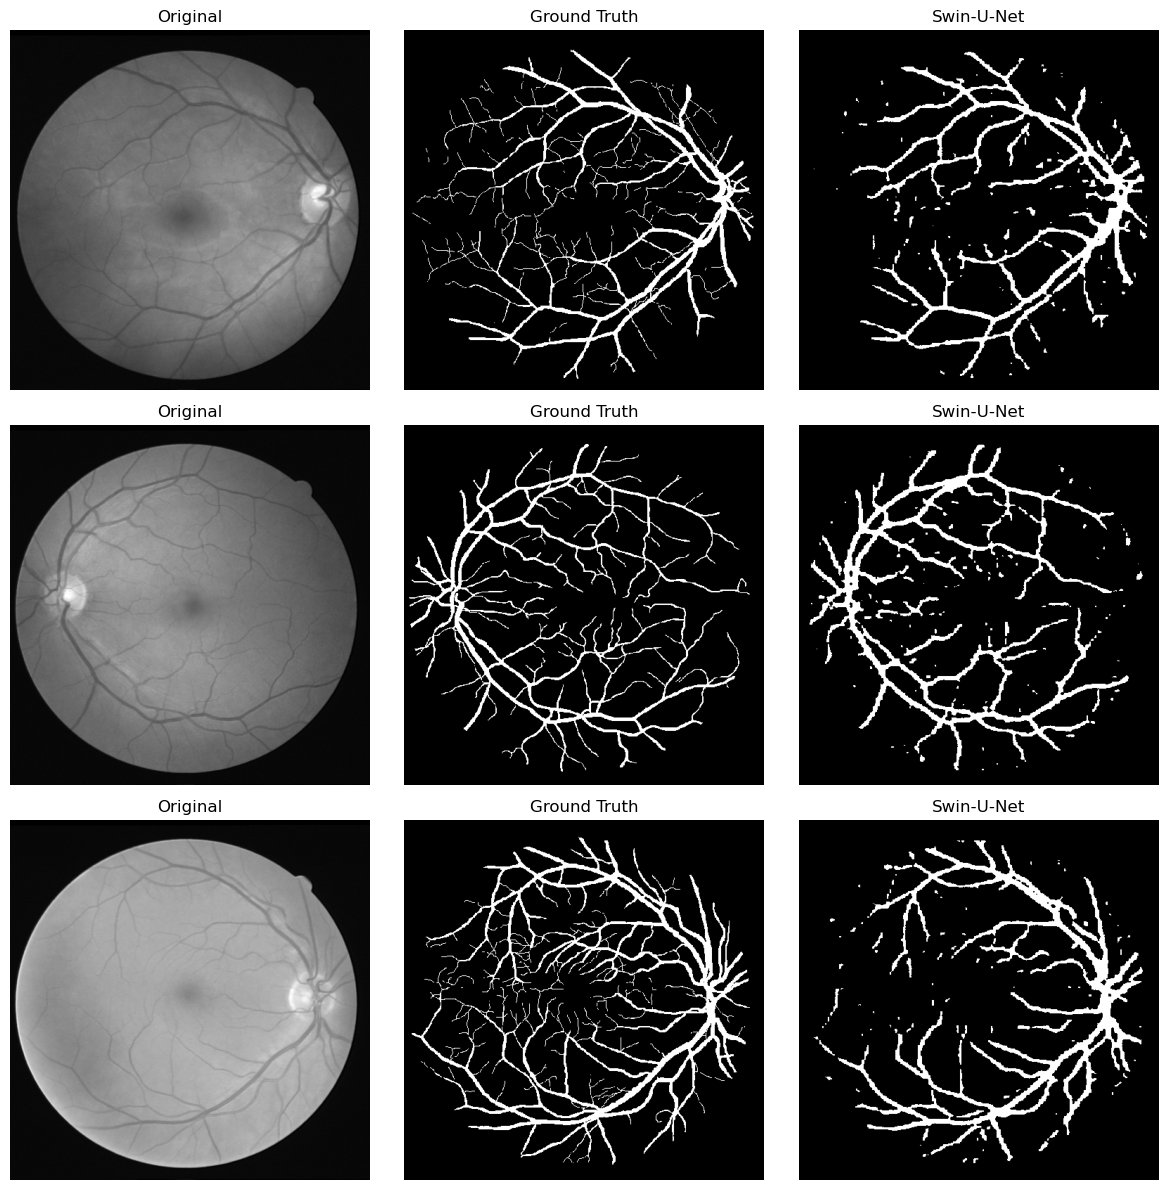

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12)
)

with torch.no_grad():

    for i in range(3):

        image, mask = val_dataset[i]

        output = swin_model(
            image.unsqueeze(0)
        )

        pred = (
            output.squeeze()
            .cpu()
            .numpy()
        )

        pred = (
            pred > 0.2
        ).astype(float)

        image = (
            image.squeeze()
            .cpu()
            .numpy()
        )

        mask = (
            mask.squeeze()
            .cpu()
            .numpy()
        )

        # Original Image

        axes[i, 0].imshow(
            image,
            cmap="gray"
        )

        axes[i, 0].set_title(
            "Original"
        )

        axes[i, 0].axis("off")

        # Ground Truth

        axes[i, 1].imshow(
            mask,
            cmap="gray"
        )

        axes[i, 1].set_title(
            "Ground Truth"
        )

        axes[i, 1].axis("off")

        # Prediction

        axes[i, 2].imshow(
            pred,
            cmap="gray"
        )

        axes[i, 2].set_title(
            "Swin-U-Net"
        )

        axes[i, 2].axis("off")

plt.tight_layout()

plt.show()

###  Let us fine-tune the Best saved model

### Load Best Swin-U-Net

In [37]:
swin_model = SwinUNet()

swin_model.load_state_dict(
    torch.load(
        "best_swin_unet_drive.pth"
    )
)

swin_model.eval()

print("Best Swin-U-Net Loaded")

Best Swin-U-Net Loaded


### Create Fine-Tuning Optimizer

Use a much smaller learning rate.

In [38]:
import torch.optim as optim

optimizer = optim.AdamW(
    swin_model.parameters(),
    lr=1e-5,
    weight_decay=1e-5
)

### Keep Existing Losses

In [39]:
bce_loss = nn.BCELoss()

dice_loss = DiceLoss()

### Initialize Best Dice

Use the previous best result.

In [40]:
best_dice = 0.6741

In [41]:
fine_tune_epochs = 30

### Fine-Tuning Loop

In [42]:
for epoch in range(fine_tune_epochs):

    # ======================
    # TRAIN
    # ======================

    swin_model.train()

    train_loss = 0

    for images, masks in train_loader:

        outputs = swin_model(images)

        bce = bce_loss(
            outputs,
            masks
        )

        dice = dice_loss(
            outputs,
            masks
        )

        loss = bce + dice

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = (
        train_loss / len(train_loader)
    )

    # ======================
    # VALIDATION
    # ======================

    swin_model.eval()

    val_loss = 0

    val_dice = 0

    with torch.no_grad():

        for val_images, val_masks in val_loader:

            val_outputs = swin_model(
                val_images
            )

            bce = bce_loss(
                val_outputs,
                val_masks
            )

            dice = dice_loss(
                val_outputs,
                val_masks
            )

            loss = bce + dice

            val_loss += loss.item()

            val_dice += dice_score(
                val_outputs,
                val_masks
            )

    avg_val_loss = (
        val_loss / len(val_loader)
    )

    avg_val_dice = (
        val_dice / len(val_loader)
    )

    # ======================
    # SAVE BEST MODEL
    # ======================

    if avg_val_dice > best_dice:

        best_dice = avg_val_dice

        torch.save(
            swin_model.state_dict(),
            "best_swin_unet_finetuned.pth"
        )

        print(
            f"\nNew Best Fine-Tuned Swin-U-Net Saved! "
            f"Dice={best_dice:.4f}"
        )

    # ======================
    # LOGGING
    # ======================

    print(
        f"Fine-Tune Epoch [{epoch+1}/{fine_tune_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice Score: {avg_val_dice:.4f} | "
        f"Best Dice: {best_dice:.4f}"
    )

Fine-Tune Epoch [1/30] | Train Loss: 0.4642 | Val Loss: 0.6143 | Dice Score: 0.6697 | Best Dice: 0.6741
Fine-Tune Epoch [2/30] | Train Loss: 0.4566 | Val Loss: 0.6158 | Dice Score: 0.6585 | Best Dice: 0.6741
Fine-Tune Epoch [3/30] | Train Loss: 0.4543 | Val Loss: 0.6142 | Dice Score: 0.6671 | Best Dice: 0.6741
Fine-Tune Epoch [4/30] | Train Loss: 0.4494 | Val Loss: 0.6160 | Dice Score: 0.6717 | Best Dice: 0.6741
Fine-Tune Epoch [5/30] | Train Loss: 0.4468 | Val Loss: 0.6151 | Dice Score: 0.6640 | Best Dice: 0.6741
Fine-Tune Epoch [6/30] | Train Loss: 0.4464 | Val Loss: 0.6159 | Dice Score: 0.6676 | Best Dice: 0.6741
Fine-Tune Epoch [7/30] | Train Loss: 0.4429 | Val Loss: 0.6172 | Dice Score: 0.6684 | Best Dice: 0.6741

New Best Fine-Tuned Swin-U-Net Saved! Dice=0.6742
Fine-Tune Epoch [8/30] | Train Loss: 0.4393 | Val Loss: 0.6206 | Dice Score: 0.6742 | Best Dice: 0.6742
Fine-Tune Epoch [9/30] | Train Loss: 0.4355 | Val Loss: 0.6204 | Dice Score: 0.6711 | Best Dice: 0.6742
Fine-Tune Epo

### Let us visualise the fine-tuned validation samples

### Load Fine-Tuned Model

In [43]:
swin_model = SwinUNet()

swin_model.load_state_dict(
    torch.load(
        "best_swin_unet_finetuned.pth"
    )
)

swin_model.eval()

print(
    "Fine-Tuned Swin-U-Net Loaded"
)

Fine-Tuned Swin-U-Net Loaded


### Visualize 3 Validation Samples

Use exactly the same visualization pipeline.

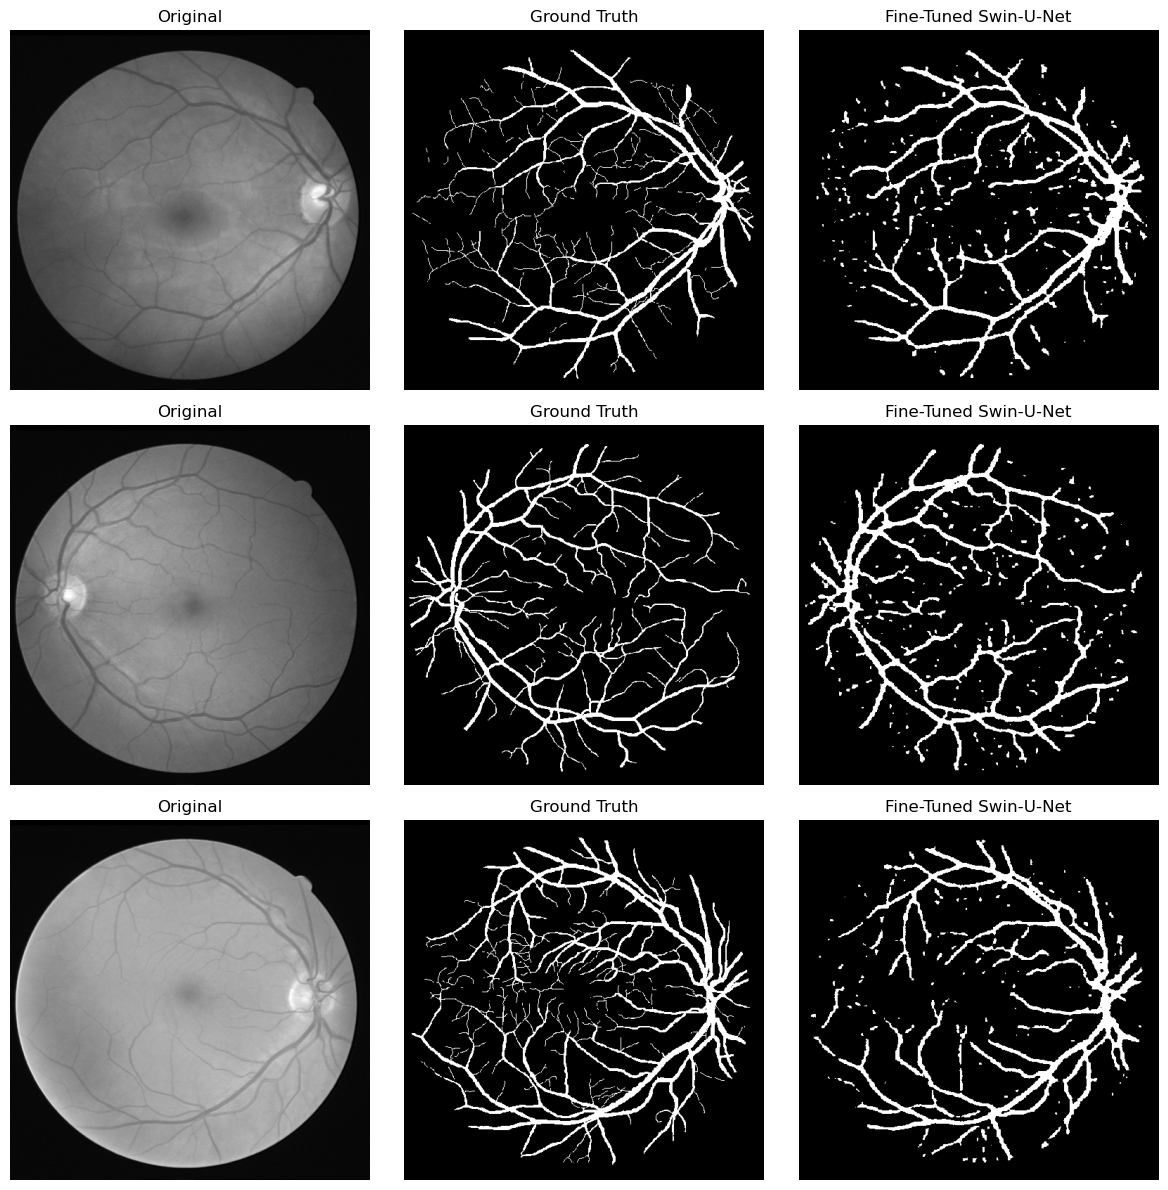

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12)
)

with torch.no_grad():

    for i in range(3):

        image, mask = val_dataset[i]

        output = swin_model(
            image.unsqueeze(0)
        )

        pred = (
            output.squeeze()
            .cpu()
            .numpy()
        )

        pred = (
            pred > 0.2
        ).astype(float)

        image = (
            image.squeeze()
            .cpu()
            .numpy()
        )

        mask = (
            mask.squeeze()
            .cpu()
            .numpy()
        )

        # Original Image

        axes[i, 0].imshow(
            image,
            cmap="gray"
        )

        axes[i, 0].set_title(
            "Original"
        )

        axes[i, 0].axis("off")

        # Ground Truth

        axes[i, 1].imshow(
            mask,
            cmap="gray"
        )

        axes[i, 1].set_title(
            "Ground Truth"
        )

        axes[i, 1].axis("off")

        # Fine-Tuned Prediction

        axes[i, 2].imshow(
            pred,
            cmap="gray"
        )

        axes[i, 2].set_title(
            "Fine-Tuned Swin-U-Net"
        )

        axes[i, 2].axis("off")

plt.tight_layout()

plt.show()

### RETINAL VESSEL SEGMENTATION USING SWIN U-NET MODEL
Abstract

Retinal vessel segmentation is a critical task in ophthalmic image analysis and computer-aided diagnosis systems. Accurate extraction of retinal blood vessels facilitates the early detection of diseases such as diabetic retinopathy, glaucoma, hypertension, and retinal vascular abnormalities. Traditional convolutional neural networks have achieved remarkable success in medical image segmentation; however, recent advances in Transformer-based architectures have introduced new opportunities for capturing long-range spatial dependencies and global contextual information.

This project investigates the application of a Swin U-Net model for retinal vessel segmentation using the DRIVE dataset. The architecture combines a Swin Transformer encoder with a U-Net-style decoder to leverage both global feature representation and hierarchical feature reconstruction. The model was trained using a combination of Binary Cross Entropy Loss and Dice Loss and evaluated using the Dice Similarity Coefficient (DSC).

Experimental results demonstrated that the Swin U-Net model successfully recovered major retinal vessel structures and achieved a best validation Dice Score of 0.6741. Additional fine-tuning improved the score marginally to 0.6752. Qualitative analysis revealed that while the model accurately identified vessel locations and recovered major arteries and veins, complete capillary continuity remained challenging due to the limited size of the training dataset.

1. Introduction

Retinal vessel segmentation is one of the most important preprocessing tasks in retinal image analysis. Blood vessel morphology provides valuable information for diagnosing both ocular and systemic diseases. Automated segmentation methods reduce dependence on manual annotation and improve diagnostic efficiency.

Deep learning methods have become the dominant approach for medical image segmentation. Traditional architectures such as U-Net utilize convolutional operations to capture local image features. However, convolutional neural networks often struggle to model long-range spatial dependencies, particularly in complex vascular structures.

Transformer-based architectures address this limitation through self-attention mechanisms that enable the model to capture global contextual information across the image. The Swin Transformer introduces a hierarchical vision transformer architecture that performs attention within shifted local windows, significantly reducing computational complexity while preserving global representation capabilities.

This project explores the effectiveness of Swin U-Net for retinal vessel segmentation and compares its performance with previously developed CNN-based 
segmentation models.














2. Dataset Description
2.1 DRIVE Dataset

The Digital Retinal Images for Vessel Extraction (DRIVE) dataset is a publicly available benchmark dataset widely used for retinal vessel segmentation research.

Dataset Components:

* Retinal Fundus Images
* Manual Vessel Annotations
* Field of View Masks

Original Dataset:

* Training Images: 20
* Vessel Masks: 20
* FOV Masks: 20

The testing set did not contain manual vessel annotations suitable for supervised learning experiments. Therefore, the original training dataset was divided into:

* Training Set: 16 Images
* Validation Set: 4 Images

This partition enabled supervised training and quantitative evaluation.










3. Data Preprocessing

The following preprocessing steps were applied:

Image Conversion

Retinal fundus images were converted to grayscale.

Normalization

Pixel intensities were normalized to the range:

* 0 – 1

* Tensor Conversion

Images and masks were converted into PyTorch tensors.

Resizing

To satisfy Swin Transformer input requirements, images were resized from:

* 584 × 565

to:

* 512 × 512

This ensured compatibility with patch-based transformer processing.








4. Swin U-Net Architecture
4.1 Overview

The Swin U-Net architecture consists of:

* Swin Transformer Encoder
* U-Net Decoder
* Skip Connections
* Final Segmentation Layer

The encoder extracts hierarchical feature representations using transformer blocks, while the decoder reconstructs pixel-level segmentation masks.



4.2 Swin Transformer Encoder

The encoder was implemented using the PyTorch Image Models (TIMM) library.

Model Configuration:

* swin_tiny_patch4_window7_224

Key Components:

* Patch Embedding

The input image is divided into non-overlapping patches.

Patch Size:

* 4 × 4

For a 512 × 512 image:

* 512 ÷ 4 = 128

resulting in a hierarchical patch representation.

Window-Based Self-Attention

Instead of computing attention across the entire image, attention is calculated within local windows.

Window Size:

* 7 × 7

This significantly reduces computational cost.

Shifted Window Mechanism

Adjacent layers shift attention windows to enable communication between neighboring regions and capture global context.

4.3 Encoder Feature Maps

The Swin Transformer encoder generated the following hierarchical feature representations:

Feature 0:

* 128 × 128 × 96

Feature 1:

* 64 × 64 × 192

Feature 2:

* 32 × 32 × 384

Feature 3:

* 16 × 16 × 768

These feature maps were extracted using:

* features_only=True

and served as skip connections for the decoder network.

4.4 Decoder Architecture

A U-Net-style decoder was designed using:

* ConvTranspose2D Layers
* Convolution Blocks
* Batch Normalization
* ReLU Activation Functions

Decoder Reconstruction Path:

* 16 × 16 × 768
↓
* 32 × 32 × 384
↓
* 64 × 64 × 192
↓
* 128 × 128 × 96
↓
* 512 × 512 × 1

The decoder progressively restored spatial resolution while integrating information from encoder skip connections.















5. Loss Functions

To address segmentation challenges and class imbalance, a hybrid loss function was adopted.

Binary Cross Entropy Loss

BCE Loss measures pixel-wise classification accuracy between predicted masks and ground truth annotations.

Advantages:

* Stable optimization
* Effective binary classification
* Dice Loss

Dice Loss directly optimizes overlap between predicted vessel masks and reference annotations.

Advantages:

* Handles class imbalance
* Improves vessel-region matching
* Combined Loss Function

Total Loss:

* Loss = BCE Loss + Dice Loss

This formulation balances pixel accuracy and region overlap.









6. Experimental Setup

Framework:

* Python
* PyTorch
* TIMM

Optimizer:

* AdamW

Initial Learning Rate:

* 0.0001

Fine-Tuning Learning Rate:

* 0.00001

Batch Size:

* 2

Training Epochs:

* 50

Fine-Tuning Epochs:

* 30

Evaluation Metric:

Dice Similarity Coefficient (DSC)











7. Results
7.1 Initial Swin U-Net Training

The model was trained for 50 epochs.

Best Validation Performance:

* Dice Score = 0.6741

Training Behavior:

Stable convergence
Progressive improvement throughout training
No evidence of optimization instability

7.2 Fine-Tuning Experiment

The best-performing checkpoint was further fine-tuned for 30 additional epochs using a reduced learning rate.

Best Fine-Tuned Performance:

* Dice Score = 0.6752

Improvement:

* 0.6741 → 0.6752

Although training loss continued to decrease, validation performance exhibited only marginal improvement, indicating performance saturation.












8. Qualitative Analysis

Visual inspection of validation predictions provided additional insights beyond numerical metrics.

Strengths

The Swin U-Net model successfully achieved:

* ✓ Major artery segmentation

* ✓ Major vein segmentation

* ✓ Accurate vessel localization

* ✓ Preservation of vessel tree structure

* ✓ Recovery of medium-sized vessel branches

The model consistently identified vessel regions and produced anatomically meaningful segmentations.



Observed Limitations

Despite successful vessel localization, several challenges remained:

* ✗ Terminal vessel discontinuity

* ✗ Incomplete capillary connectivity

* ✗ Small gaps between vessel endings

* ✗ Limited recovery of ultra-thin vascular structures

Interestingly, many missing vessel segments appeared in approximately correct locations but failed to form continuous vessel structures.

This observation suggests that the model learned vessel presence but struggled to learn complete vessel topology.









9. Discussion

The Swin U-Net architecture demonstrated the capability to extract meaningful retinal vessel representations despite the limited size of the training dataset.

The Transformer encoder successfully captured global contextual information and accurately localized vessel structures. However, complete capillary continuity was not achieved even after additional fine-tuning.

Several factors may explain this behavior:

Dataset Size Limitation

The model was trained using only:

* 16 training images

Transformers typically require substantially larger datasets to fully exploit their representation learning capabilities.

Vessel Topology Complexity

Retinal capillaries exhibit extremely fine and complex branching structures that are difficult to learn from limited examples.

Loss Function Limitation

The combined BCE and Dice losses optimize pixel-level agreement but do not explicitly encourage topological continuity.

As a result, disconnected vessel fragments may receive similar optimization rewards as fully connected vessel structures.








10. Comparative Perspective

The Swin U-Net model was compared against previously developed CNN-based architectures.

* Model	Best Dice Score
* U-Net	0.7188
* Attention U-Net	0.7513
* Swin U-Net	0.6741
* Swin U-Net Fine-Tuned	0.6752

Although Swin U-Net demonstrated strong vessel localization capabilities, CNN-based Attention U-Net achieved superior quantitative and qualitative performance on the limited DRIVE dataset.

This finding suggests that convolutional architectures remain more data-efficient when training samples are scarce.












11. Conclusion

This study investigated the application of a Swin U-Net model for retinal vessel segmentation using the DRIVE dataset.

The model successfully extracted major retinal vessel structures and demonstrated stable learning behavior throughout training. The Swin Transformer encoder effectively captured hierarchical vessel representations and produced anatomically meaningful segmentation masks.

The best model achieved a validation Dice Score of 0.6741, while additional fine-tuning improved performance marginally to 0.6752.

Visual analysis revealed that the model accurately localized vessel structures but struggled to achieve complete capillary continuity. The persistence of disconnected vessel endings suggests that the primary limitation may be the small dataset size and the absence of topology-aware optimization objectives.

Future work should investigate:

* Larger retinal datasets
* Multi-dataset training (DRIVE, STARE, CHASE_DB1)
* Focal Loss
* Topology-Aware Loss Functions
* Hybrid CNN-Transformer Architectures
* Self-Supervised Pretraining

These approaches may further improve vessel continuity and fine-vessel recovery in retinal vessel segmentation tasks.

References

Dosovitskiy, A., et al. (2021). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.

Liu, Z., Lin, Y., Cao, Y., et al. (2021). Swin Transformer: Hierarchical Vision Transformer using Shifted Windows.

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation.

Staal, J., Abramoff, M., Niemeijer, M., Viergever, M., & Van Ginneken, B. DRIVE: Digital Retinal Images for Vessel Extraction Dataset.